In [1]:
import pandas as pd
import numpy as np 
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from stats_weapons import normality_tests, correlation_analysis

In [2]:
x1 = np.linspace(-1.5, 1.5, 100)
x2 = np.linspace(-1.5, 1.5, 100)
x1, x2 = np.meshgrid(x1, x2)

rbrock = (1 - x1)**2 + 100 * (x2 - x1**2)**2
restr = np.maximum(x1**2 + x2**2 - 1, 0)

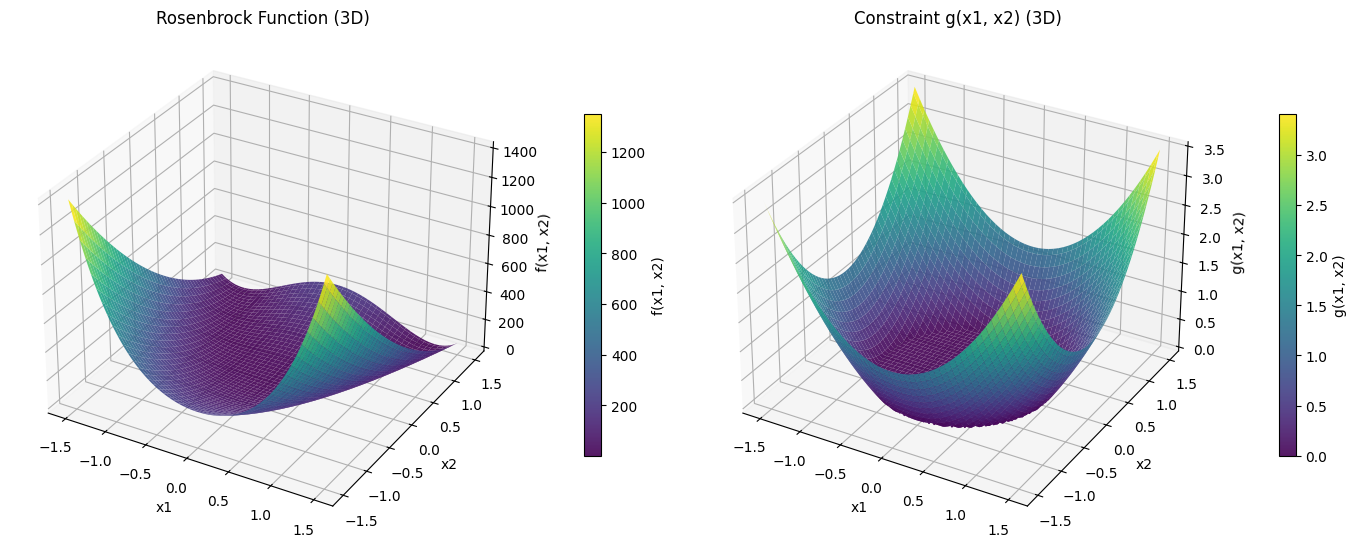

In [3]:
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(x1, x2, rbrock, cmap='viridis', edgecolor='none', alpha=0.9)
fig.colorbar(surf1, ax=ax1, shrink=0.6, pad=0.1, label='f(x1, x2)')
ax1.set_title('Rosenbrock Function (3D)')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('f(x1, x2)')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(x1, x2, restr, cmap='viridis', edgecolor='none', alpha=0.9)
fig.colorbar(surf2, ax=ax2, shrink=0.6, pad=0.1, label='g(x1, x2)')
ax2.set_title('Constraint g(x1, x2) (3D)')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('g(x1, x2)')

plt.tight_layout()

plt.show()

##### O vale largo e plano dessa função indica que há alta colinearidade quando o espaço de busca consegue sair das paredes da F(x1, x2)

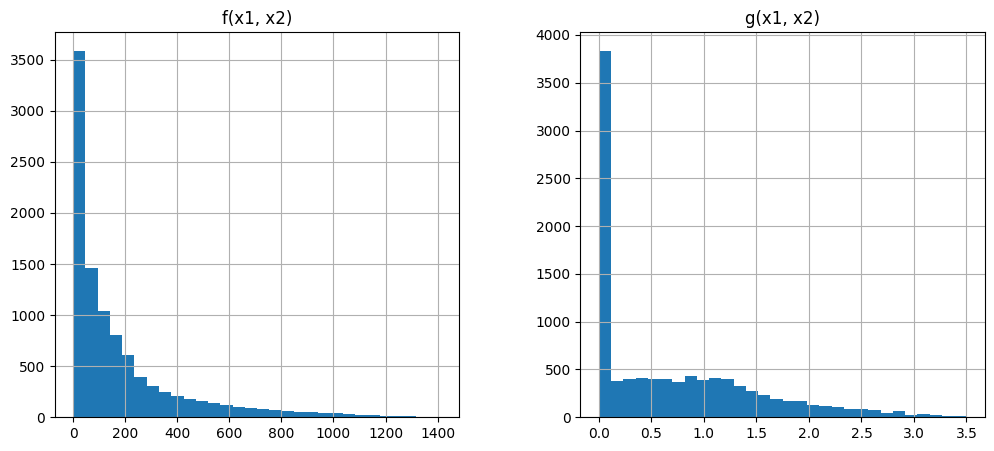

In [4]:
# Analisando as variaveis de decisão e as funções objetivo e restrição
df = pd.DataFrame({'x1': x1.flatten(), 'x2': x2.flatten(), 'f(x1, x2)': rbrock.flatten(), 'g(x1, x2)': restr.flatten()})

hist = df.hist(column=['f(x1, x2)', 'g(x1, x2)'], bins=30, figsize=(12, 5))


=====> Normality Tests Results <=====

===> Feature: f(x1, x2)
Sample Size: 10000
Shapiro-Wilk test is not recommended for sample size >= 2000. Skipping...

>> Kolmogorov-Smirnov Test

Statistic: 0.2206, 
P-value: 0.0000, 
Interpretation: Not Normal

>> Anderson-Darling Test

Statistic: 841.0156, 
Critical Values: [0.561 0.631 0.752 0.873 1.035], 
Significance Level: [15.  10.   5.   2.5  1. ], 
P-value: 0.0000, 
Interpretation: Not Normal

>> D'Agostino and Pearson's Test

Statistic: 4094.1692, 
P-value: 0.0000, 
Interpretation: Not Normal

>> Jarque-Bera Test

Statistic: 15504.6775, 
P-value: 0.0000, 
Interpretation: Not Normal


c:\Users\RNYC\OneDrive - Novo Nordisk\Área de Trabalho\Codar\rosenbrock\stats_weapons.py:441: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  statistic, critical_values, significance_level = stats.anderson(data, dist='norm')


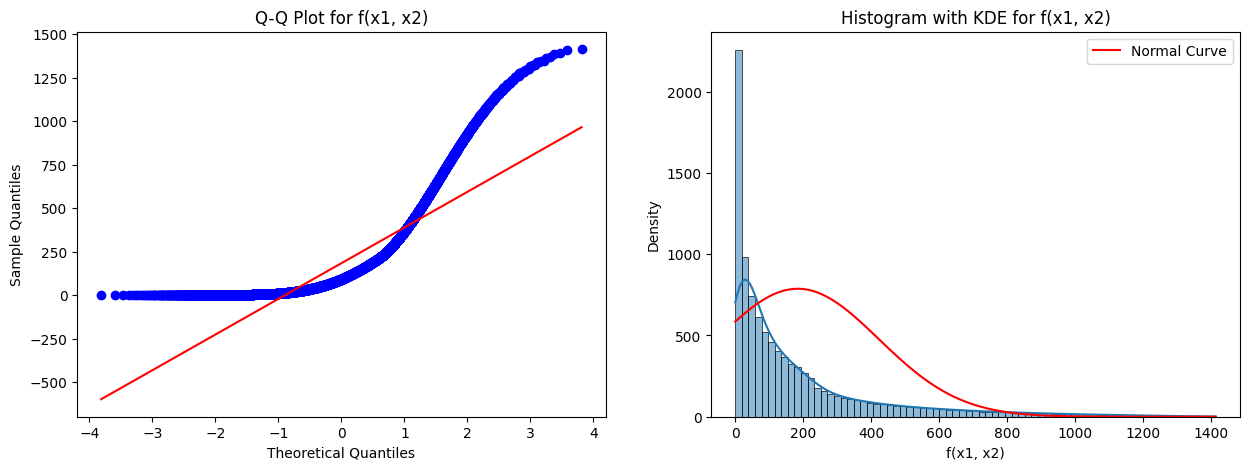


===> Feature: g(x1, x2)
Sample Size: 10000
Shapiro-Wilk test is not recommended for sample size >= 2000. Skipping...

>> Kolmogorov-Smirnov Test

Statistic: 0.1849, 
P-value: 0.0000, 
Interpretation: Not Normal

>> Anderson-Darling Test

Statistic: 506.9371, 
Critical Values: [0.561 0.631 0.752 0.873 1.035], 
Significance Level: [15.  10.   5.   2.5  1. ], 
P-value: 0.0000, 
Interpretation: Not Normal

>> D'Agostino and Pearson's Test

Statistic: 1310.2429, 
P-value: 0.0000, 
Interpretation: Not Normal

>> Jarque-Bera Test

Statistic: 1883.7155, 
P-value: 0.0000, 
Interpretation: Not Normal


c:\Users\RNYC\OneDrive - Novo Nordisk\Área de Trabalho\Codar\rosenbrock\stats_weapons.py:441: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  statistic, critical_values, significance_level = stats.anderson(data, dist='norm')


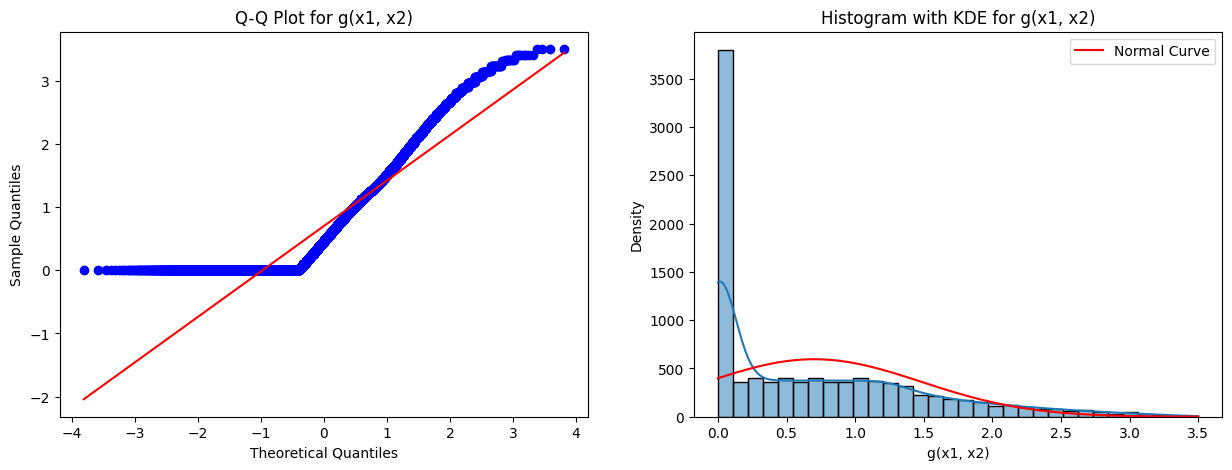

In [5]:
# testando normalidade das funções objetivo e restrição
normality_results = normality_tests(df[['f(x1, x2)', 'g(x1, x2)']], methodology='all', alpha=0.05)

##### Resultado: obviamente não normais, confirmado estatisticamente com confiança aceitável


=====> Correlation Analysis w/ Outliers <=====

===> Pearson Correlation Matrix
           f(x1, x2)  g(x1, x2)
f(x1, x2)    1.00000    0.60112
g(x1, x2)    0.60112    1.00000


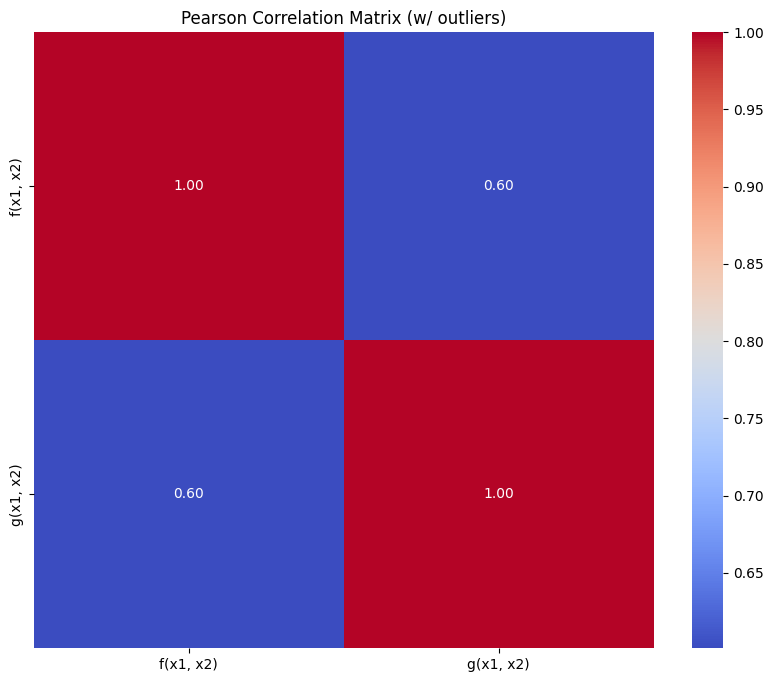


=====> Correlation Analysis w/o Outliers <=====

===> Pearson Correlation Matrix
           f(x1, x2)  g(x1, x2)
f(x1, x2)   1.000000   0.515471
g(x1, x2)   0.515471   1.000000


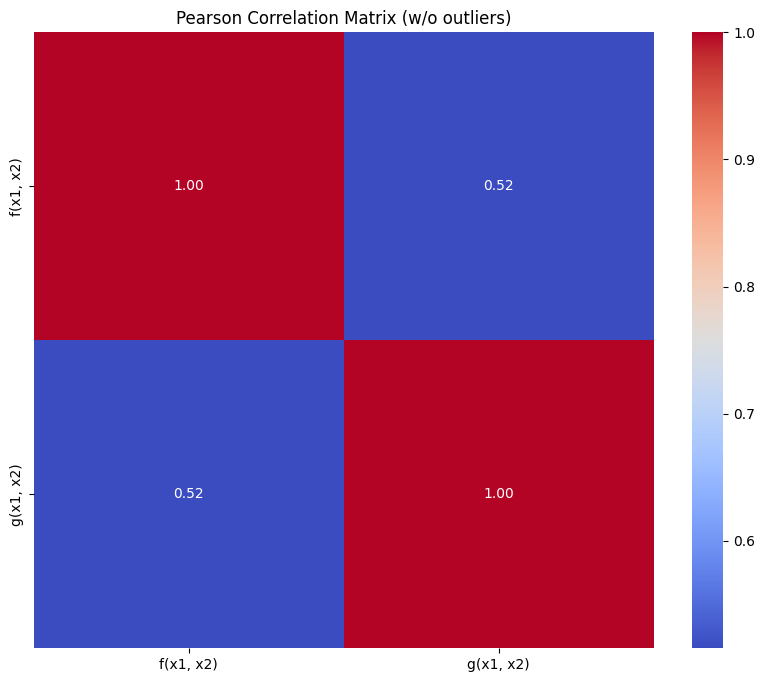


=====> Scatter-Plots <=====


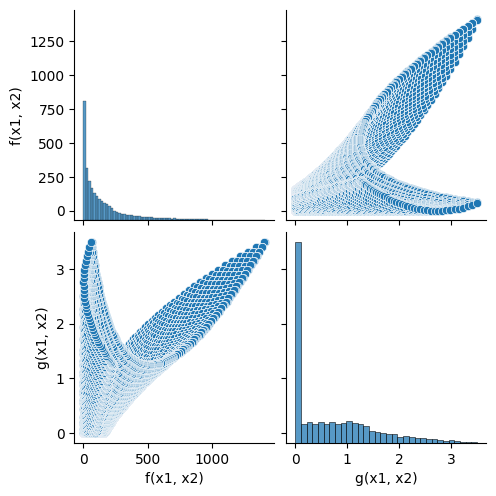


=====> Interpretation of Pearson's Correlation Results <=====

===> Target feature '{target}' correlations: 
g(x1, x2)    0.60112
Name: f(x1, x2), dtype: float64

===> Strenght of relationships
'g(x1, x2)' has **MODERATE** correlation with target 'f(x1, x2)' : |r| = 0.60

===> Redundancy, Multicolinearity and Dimensionality Reduction Assessment : |r| > 0.8
No highly redundant realtionship found between 'f(x1, x2)' and 'f(x1, x2)'
No highly redundant realtionship found between 'f(x1, x2)' and 'g(x1, x2)'
No highly redundant realtionship found between 'g(x1, x2)' and 'f(x1, x2)'
No highly redundant realtionship found between 'g(x1, x2)' and 'g(x1, x2)'

===> Strong Predictors for Regression Models
No features with strong predictive power for 'f(x1, x2)' found.


In [6]:
corr = correlation_analysis(df[['f(x1, x2)', 'g(x1, x2)']], target='f(x1, x2)', )

##### Uma correlação de r = 0.60 já indica certa correlação entre as variáveis de decisão, talvez seja útil transformar iterativamente a base do sistema na direção dos autovetores da matriz de covariância para simplificar a busca na região do vale. No contexto de otimização essa técnica é chamada de "eigenvector crossover", no contexto mais amplo de ciência de dados e machine learning ela é chamada de análise de componentes principais (PCA)

In [7]:
cov_matrix = np.cov(df['f(x1, x2)'], df['g(x1, x2)'])
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[5.68459485e+04 1.12100190e+02]
 [1.12100190e+02 6.11772960e-01]]


##### Portanto, atesta-se a colinearidade devido covariâncias expressivas